<a href="https://colab.research.google.com/github/arthurflor23/handwritten-text-recognition/blob/master/tutorial.ipynb" target="_parent"><img src="https://img.shields.io/badge/Colab-F9AB00?style=for-the-badge&logo=googlecolab&color=525252" alt="Open In Colab"/></a>
<a href="https://ko-fi.com/arthurflor23" target="_parent"><img src="https://img.shields.io/badge/Ko--fi-F16061?style=for-the-badge&logo=ko-fi&logoColor=white" alt="Support on Ko-fi"/></a>


<a href="https://github.com/arthurflor23/handwritten-text-recognition" target="_parent">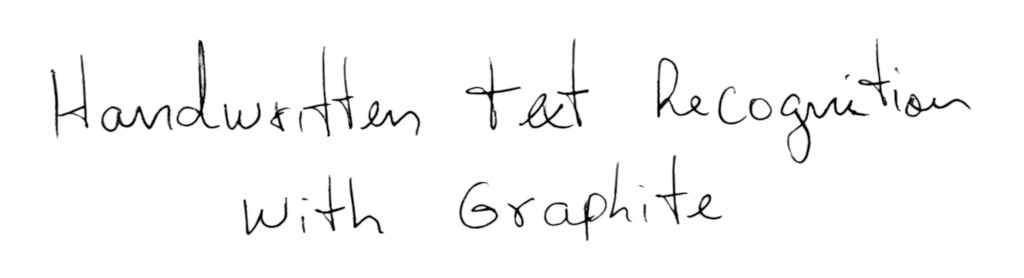</a>


# Handwritten Text Recognition with Graphite


## 1\. Introduction


In this tutorial, we'll explore [Graphite](https://github.com/arthurflor23/handwritten-text-recognition), a solution for Handwritten Text Recognition (HTR). We'll guide you through the process of setting up your environment and preparing your dataset. Then, we'll present the model training, prediction, evaluation, and samples sections. This will give you insights into the project, enabling you to apply what you learn to your own context.

In addition, we'll only explore the `recognition` workflow, since generative models are expensive and time is money. Even so, if you're really into it, feel free to dive deeper into the project's code. Also, don't forget to give a quick look in the [README.md](https://github.com/arthurflor23/handwritten-text-recognition/blob/master/README.md) and further documentation before jumping into this tutorial.

## 2\. Data Environment


In this section, we'll set up the data environment to ensure a smooth execution of the handwriting recognition process. We'll cover the datasets you'll be working with and how to incorporate custom datasets into Graphite.


### 2\.1\. Datasets


The project supports a wide range of datasets for handwritten text recognition. The most famous datasets are already integrated into the project and can be easily used for training and evaluation. To access them you can find [here](https://github.com/arthurflor23/handwritten-text-recognition?tab=readme-ov-file#datasets).

To use the datasets, ensure that they are placed in the `datasets` folder with their default names. This folder structure allows for seamless integration with the project and ensures that the datasets are easily accessible during the training and evaluation processes.

In addition, you can also incorporate other custom datasets by following the same folder structure and naming conventions. Feel free to explore these datasets or incorporate your own to tailor the HTR system to your specific needs.


## 3\. Colab Environment


Setting up the Colab environment properly is essential to leverage the TensorFlow with GPU acceleration and access your project files conveniently through Google Drive. This section covers the necessary steps to ensure a correct setup.


### 3\.1\. TensorFlow with GPU


To check if your Colab environment has GPU support, execute the `!nvidia-smi` command. This command displays detailed information about the available GPUs, including their memory usage. Running this command helps you verify if your Colab environment has GPU access and ensures optimal performance during training and inference.


Execute the following command:


In [ ]:
!nvidia-smi

The output will show GPU information if your Colab environment has GPU support. If you don't see any GPU information, it means that GPU access may not be available at the moment. You can still proceed with the tutorial, but note that certain computations may be slower without GPU acceleration.


### 3\.2\. Google Drive


To mount your Google Drive in Colab and access your project files, execute the following code snippet:


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

This code will prompt you to authenticate and generate an authorization code. Click on the provided link and sign in with your Google account. This process will mount your Google Drive and make it accessible within the Colab environment.


After mounting your Google Drive, you can navigate to your project folder using the `cd` command. Adapt the command below with the actual path to your project folder:


In [ ]:
%cd './drive/MyDrive/Colab Notebooks/handwritten-text-recognition/'

To verify that you are in the correct directory and see the list of files, execute the following command:


In [ ]:
!ls -l

Finally, to ensure all the required packages and dependencies are installed, make sure the `requirements.txt` file is present in your project folder and execute the following command:


In [ ]:
!pip install -q -r requirements.txt

## 4\. Dataset Class


Firstly, the project has the `Tokenizer` class, which is crucial and responsible for storing and managing the encoding and decoding of texts for the models. It is also possible to reuse a tokenizer on another dataset, which will update automatically. Thus, we need to check if there is any instance of the tokenizer along with its respective MLflow run context object. This is to load the tokenizer within the `Dataset` class and to load the model weights in the `Graphite` class.


The Dataset class manages the data source and provides options for handling the data. To create a dataset, we will use the "washington" dataset, set the text level to "line", and define the image shape. See more about the [parameters](https://github.com/arthurflor23/handwritten-text-recognition?tab=readme-ov-file#dataset).

In [ ]:
from graphite import Dataset
from graphite import Graphite


image_shape = (64, 1024, 1)
recognition = 'flor'

tokenizer, run_context = Graphite().get_tokenizer(recognition=recognition,
                                                  recognition_run_index=-1)

dataset = Dataset(source='washington',
                  text_level='line',
                  image_shape=image_shape,
                  tokenizer=tokenizer,
                  seed=1234)
dataset

**Note:** It's worth mentioning that if you want to integrate a custom source, create a new file (`<custom_source>.py`) in the `graphite/data/source/` folder. It's important to follow the same pattern as the already implemented sources. Then, you can use it by specifying the `source` parameter as `<custom_source>` when creating the Dataset object.


## 5\. Augmentor Class


The Augmentor class applies various transformations to images for data augmentation purpose. To use the Augmentor class, you can create an instance and provide the desired parameters. The values in the list for each parameter define the specific settings for that transformation. Modify these values according to your augmentation requirements. Each list generally has the first value as the probability of applying the transformation and the others as parameters of the transformation itself. See more about the [parameters](https://github.com/arthurflor23/handwritten-text-recognition?tab=readme-ov-file#augmentor).


In [ ]:
from graphite import Augmentor


augmentor = Augmentor(binarize=None,
                      erode=[0.66, 3, 1],
                      dilate=[0.33, 2, 1],
                      elastic=[0.66, 29, 1],
                      perspective=[0.66, 0.4],
                      mixup=None,
                      shear=[0.33, 15],
                      scale=[0.33, 0.1],
                      rotate=[0.33, 1.0],
                      shift_y=None,
                      shift_x=None,
                      salt_and_pepper=None,
                      gaussian_noise=None,
                      gaussian_blur=None,
                      seed=1234)
augmentor

## 6\. Graphite Class


The Graphite class manages the models and the MLflow tracking. In this way, it manages the recognition model, synthesis model, and the combination of both. In general, is the core instance for the models implementations and manage the common pipelines (compile, fit, predict, evaluate, and so on). Once an instance is created, you can compile the class model providing the run context to load and continue the training phase. For this tutorial, we'll use the "flor" as the recognition model. It's important to note that classes share information between parameters.

In [ ]:
from graphite import Graphite


graphite = Graphite(recognition=recognition,
                    image_shape=image_shape,
                    tokenizer=dataset.tokenizer)

graphite.compile(learning_rate=0.001, run_context=run_context)
graphite

# graphite.model.recognition.summary()

**Note:** Just like creating a custom source, if you want to integrate a custom model, create a new file (`<custom_model>.py`) in the `graphite/models/{synthesis,recognition}/` folder. It's important to follow the same pattern as the already implemented networks to ensure consistency within the Graphite project. Then, you can use it by specifying the `{synthesis,recognition}` parameters as `<custom_model>` when creating the Model object.


### 6\.1\. Model Training


In this subsection, we'll cover the process of training the recognition model using the specified dataset and augmentor. The following code snippet demonstrates the steps involved in this phase:


In [ ]:
epochs = 10000
batch_size = 8

plateau_factor = 0.1
plateau_cooldown = 0
plateau_patience = 20
patience = 40

training_gen, training_steps = dataset.get_generator(data_partition='training',
                                                     batch_size=batch_size,
                                                     augmentor=augmentor,
                                                     shuffle=True)

validation_gen, validation_steps = dataset.get_generator(data_partition='validation',
                                                         batch_size=batch_size)

graphite.fit(training_gen=training_gen,
             training_steps=training_steps,
             validation_gen=validation_gen,
             validation_steps=validation_steps,
             plateau_factor=plateau_factor,
             plateau_cooldown=plateau_cooldown,
             plateau_patience=plateau_patience,
             patience=patience,
             epochs=epochs)

Let's break down the steps:

1. **Generate Training and Validation Data Generators:** The `get_generator` method of the `Dataset` class was used to generate data generators for the training and validation partitions. Thus, the `data_partition` parameter specify the corresponding partition to be used. The `batch_size` determines the number of samples per batch. The `augmentor` is used to apply augmentation techniques to the data. In this example, the `augmentor` is used for training data, while no augmentation is applied to the validation data by passing `augmentor=None`.

2. **Fit the Model:** The `fit` method of the `Graphite` class is used to train the model. The `epochs` parameter specifies the maximum number of training epochs. The `training_gen` and `validation_gen` parameters accept the data generator, where the `training_steps` and `validation_steps` specify the number of steps per epoch for training and validation, respectively. Other parameters such as `plateau_factor`, `plateau_cooldown`, `plateau_patience`, `patience`, and `verbose` control aspects of the training process.


Executing this code will initiate the training process for the recognition model on the provided dataset, augmentation techniques, and specified training parameters. Feel free to adjust the parameters based on your requirements to achieve optimal model performance.


### 6\.2\. Model Prediction


In this subsection, we'll present how to use the trained model to make predictions on test data. Thus, after training the recognition model, we'll use it for making predictions on unseen data. The following code snippet demonstrates how to perform model prediction:


In [ ]:
batch_size = 8
top_paths = 1
beam_width = 32

test_gen, test_steps = dataset.get_generator(data_partition='test',
                                             batch_size=batch_size)

predictions, probabilities = graphite.predict_recognition(x=test_gen,
                                                          steps=test_steps,
                                                          top_paths=top_paths,
                                                          beam_width=beam_width,
                                                          ctc_decode=True,
                                                          token_decode=True,
                                                          verbose=1)

Let's break down the steps:

1. **Generate Test Data Generator:** The `get_generator` method of the `Dataset` class was used to generate data generators for the test partition. Thus, the `data_partition` parameter specifies the test subset, and the `batch_size` parameter determines the number of samples per batch.

2. **Perform Predictions:** The `predict_recognition` method of the `Graphite` class is used to make predictions on the test data, specifically for recognition task. The `x` parameter accepts the data generator, where the `steps` parameter specifies the number of steps for the data subset. Other parameters such as `top_paths`, `beam_width`, `ctc_decode`, `token_decode`, and `verbose` control aspects of the prediction process.


The prediction will generate new data using the trained recognition model on the unseen test data. The predicted outputs will be stored in the `predictions` and `probabilities` variables. Both will be important in the next stage of evaluation.

### 6\.3\. Model Evaluation


In this subsection, we'll evaluate the model's performance by comparing its predictions with ground truth data. To do this, use the subset of tests and predictions generated previously to obtain the `metrics` and `evaluations`.

In [ ]:
source_gen, source_steps = dataset.get_generator(data_partition='test',
                                                 batch_size=batch_size,
                                                 batch_encoded=False)

metrics, evaluations = graphite.evaluate_recognition(x=predictions,
                                                     y=source_gen,
                                                     steps=source_steps,
                                                     probabilities=probabilities,
                                                     verbose=1)
metrics

**Note:** To evaluate the predictions, we need to create a generator for the raw data. In the recognition workflow, this represents texts in string format, and this process is achieved through the `batch_encoded` flag. Finally, the `evaluate_recognition` method calculates the metrics and creates a json with all the evaluations performed. To visualize the evaluations, you can use json module to indent.


In [ ]:
import json

print(json.dumps(evaluations, indent=4))

### 6\.4\. MLflow Context

While the model is trained, some informations are saved during and after the process. However, to save more application context, you should save it manually.


In [ ]:
graphite.save_context(dataset=dataset,
                      augmentor=augmentor,
                      model=graphite.model,
                      metrics=metrics,
                      evaluations=evaluations)

Once the `save_context` method is called, MLflow will save all data into artifacts path. This information can then be easily accessed and tracked using the MLflow Dashboard (`mlflow ui`).


## 7\. Samples


Finally, we'll visualize samples from the test dataset and compare the ground truth with the model's prediction. By iterating over the test data, we can examine the accuracy on individual examples and gain insights into its performance.


In [ ]:
import matplotlib.pyplot as plt


source_gen, _ = dataset.get_generator(data_partition='test',
                                      batch_size=batch_size,
                                      batch_encoded=False)

sample_gen, _ = dataset.get_generator(data_partition='test',
                                      batch_size=batch_size,
                                      batch_encoded=True,
                                      batch_processing=False)

# adjust as necessary
step = 1

for i in range(step, step + 1):
    _, y_source_data = next(source_gen)
    _, y_sample_data = next(sample_gen)

    image_source_data, text_source_data, writer_source_data = y_source_data
    image_sample_data, _, _ = y_sample_data

    for j in range(len(image_source_data)):
        print('Path image')
        print(image_source_data[j], '\n')

        print('Source writer')
        print(writer_source_data[j], '\n')

        print('Source text')
        print(text_source_data[j], '\n')

        print('Predicted text')
        print(predictions[i * j][0], '\n')

        print('Image')
        plt.figure(figsize=(6, 3))
        plt.imshow(image_sample_data[j], cmap='gray')
        plt.axis('off')
        plt.show()
        print('-' * 69, '\n')